# Introduction

## Lab2: Train a Convolutional Neural Network (CNN).

In this Lab session we will learn how to train a CNN from scratch for classifying MNIST digits.

NOTE: All text cells starting with a number indicate that you have to write code or write a response. However, read all the cells to understand the full pipeline.

IMPORTANT: The goal is for you to learn how CNNs are implemented and trained with Pytorch. Using AI to write code for you harms this learning process, so it is strictly forbidden to use AI to write code. Feel free to use AI to _learn_ about Pytorch, CNNs, etc., but you are highly encouraged to read Pytorch's very good documentation, too. Concepts you learn in this assignment will be relevant for the exam.

In [ ]:
# import necessary libraries
import torch
import torchvision
from torchvision import transforms as T
import torch.nn.functional as F

### 1. Define LeNet

![network architecture](https://www.researchgate.net/profile/Lucijano-Berus/publication/329891470/figure/fig1/AS:707347647307776@1545656229128/Architecture-of-LeNet-5-a-Convolutional-Neural-Network-for-digits-digits-recognition-An.ppm)

Here we are going to define our first CNN which is **LeNet** in this case. This architecture has been introduced and is detailed in [this article](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf). To construct a LeNet we will be using two convolutional layers followed by three fully-connected layers as indicated in the figure. The convolutional layers can be defined using `torch.nn.Conv2d` module of `torch.nn` package. Details can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Moreover, we will use a pooling operation to reduce the size of convolutional feature maps. For this case we are going to use `torch.nn.functional.max_pool2d`. Details about maxpooling can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.max_pool2d.html)

Differently from our previous Lab, we will use a Rectified Linear Units (ReLU) as activation function with the help of `torch.nn.functional.relu`, replacing `torch.nn.Sigmoid`. Details about ReLU can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.relu.html).

Note: The figure shows 32x32 input size while your data will be slightly differnt. You can either pad the input or adjust the network architecture slightly (as little as possible).

In [ ]:
from torch.nn.modules import padding
class LeNet_MNIST(torch.nn.Module):
  def __init__(self):
    super(LeNet_MNIST, self).__init__()

    # input channel = 1, output channels = 6, kernel size = 5
    # input image size = (32, 32), image output size = (28, 28)
    # DONE
    self.conv1 = torch.nn.Conv2d(1,6,kernel_size=5)

    # input channel = 6, output channels = 16, kernel size = 5
    # input image size = (14, 14), output image size = (10, 10)
    # DONE
    self.conv2 = torch.nn.Conv2d(6,16,kernel_size=5)

    # input dim = (400), output dim = (120)
    # DONE
    self.fc1 = torch.nn.Linear(400, 120)

    # input dim = (120), output dim = (84)
    # DONE
    self.fc2 = torch.nn.Linear(120, 84)

    # input dim = (84), output dim = (10)
    # DONE
    self.fc3 = torch.nn.Linear(84, 10)

  def forward(self, x):

    padding = torch.nn.modules.padding.ZeroPad2d(2)
    x = padding(x)

    x = self.conv1(x)
    x = torch.nn.functional.relu(x)

    # Max Pooling with kernel size = 2
    # output size = (14, 14)
    # DONE
    x = torch.nn.functional.max_pool2d(input=x, kernel_size=2, stride=2)

    x = self.conv2(x)
    x = torch.nn.functional.relu(x)

    # Max Pooling with kernel size = 2
    # output size = (5, 5)
    # DONE
    x = torch.nn.functional.max_pool2d(input=x, kernel_size=2, stride=2)
    x = torch.nn.functional.relu(x)

    # flatten the feature maps into a long vector
    x = x.view(x.shape[0], -1)

    x = self.fc1(x)
    x = torch.nn.functional.relu(x)
    x = self.fc2(x)
    x = torch.nn.functional.relu(x)
    x = self.fc3(x)

    return x

### 2. Define cost function
Hint: Make sure to read the documentation of the loss function you use to validate that your network output matches what the loss expects as input.

In [ ]:
def get_cost_function():
  # DONE
  cost_function = torch.nn.CrossEntropyLoss()
  return cost_function

### 3. Define the optimizer

We will use SGD with learning rate-lr, weight_decay=wd and  momentum=momentum

In [ ]:
def get_optimizer(net, lr, wd, momentum):
  # DONE
  optimizer =  torch.optim.SGD(params=net.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
  return optimizer

### Train and test functions

In [ ]:
def test(net, data_loader, cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.
  all_predictions = [] # List to store all predictions

  net.eval() # Strictly needed if network contains layers which has different behaviours between train and test
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(data_loader):
      # Load data into GPU
      inputs = inputs.to(device)
      targets = targets.to(device)

      # Forward pass
      outputs = net(inputs)

      # Apply the loss
      loss = cost_function(outputs, targets)

      # Better print something. Answer: I will print only in the main functino and can plot the results later
      samples+=inputs.shape[0]
      cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
      _, predicted = outputs.max(1)
      cumulative_accuracy += predicted.eq(targets).sum().item()
      all_predictions.append(predicted) # Store predictions for current batch

  # Concatenate all predictions into a single tensor
  all_predictions = torch.cat(all_predictions)

  return all_predictions, cumulative_loss/samples, cumulative_accuracy/samples*100


def train(net,data_loader,optimizer,cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.


  net.train() # Strictly needed if network contains layers which has different behaviours between train and test
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    # Load data into GPU
    inputs = inputs.to(device)
    targets = targets.to(device)

    # Forward pass
    outputs = net(inputs)

    # Apply the loss
    loss = cost_function(outputs,targets)

    # Reset the optimizer
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    # Better print something, no? Answer: I will print only in the main functino and can plot the results later
    samples+=inputs.shape[0]
    cumulative_loss += loss.item()
    _, predicted = outputs.max(1)
    cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100

### Define the function that fetches a data loader that is then used during iterative training.

We will learn a new thing in this function as how to Normalize the inputs given to the network.

***Why Normalization is needed***?

To have nice and stable training of the network it is recommended to normalize the network inputs between \[-1, 1\].

***How it can be done***?

This can be simply done using `torchvision.transforms.Normalize()` transform. Details can be found [here](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html).

In [ ]:
def get_data(batch_size, dataset, test_batch_size=256, use_data_augmentation=False):

  # Prepare data transformations and then combine them sequentially
  transform_list = []

  if use_data_augmentation and dataset == 'CIFAR10':
    transform_list.append(T.RandomCrop(32, padding=4))
    transform_list.append(T.RandomHorizontalFlip())

  transform_list.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  transform_list.append(T.Normalize(mean=[0.5], std=[0.5]))      # Normalizes the Tensors between [-1, 1]
  transform = T.Compose(transform_list)                          # Composes the above transformations into one.

  # Load data
  if (dataset=='MNIST'):
    full_training_data = torchvision.datasets.MNIST('./data', train=True, transform=transform, download=True)
    test_data = torchvision.datasets.MNIST('./data', train=False, transform=transform, download=True)

  elif (dataset=='CIFAR10'):
    full_training_data = torchvision.datasets.CIFAR10('./data', train=True, transform=transform, download=True)
    test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=transform, download=True)

  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.5+1)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

### 4. Initializing model and wrapping everything up

Finally, we need a main function which initializes everything + the needed hyperparameters and loops over multiple epochs (printing the results).

In [ ]:
'''
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
'''

def main(
        net,
        batch_size=128,
        device='cuda:0',
        learning_rate=0.01,
        weight_decay=0.000001,
        momentum=0.9,
        epochs=50,
        early_stop=-1,
        min_delta=0.0001,
        dataset='MNIST',
        use_data_augmentation=False,
        dropout_rate=0.0):

  patience = 0
  best_val_loss = float('inf')

  train_loader, val_loader, test_loader = get_data(batch_size,dataset=dataset, use_data_augmentation=use_data_augmentation)

  optimizer = get_optimizer(net, learning_rate, weight_decay, momentum)

  cost_function = get_cost_function()

  print('Before training:')
  _,train_loss, train_accuracy = test(net, train_loader, cost_function, device=device)
  _,val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)
  _,test_loss, test_accuracy = test(net, test_loader, cost_function, device=device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  train_metrics = {}
  train_metrics['loss'] = []
  train_metrics['acc'] = []
  train_metrics['predictions'] = []

  val_metrics = {}
  val_metrics['loss'] = []
  val_metrics['acc'] = []
  val_metrics['predictions'] = []

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function, device=device)
    _, val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)

    train_metrics['loss'].append(train_loss)
    train_metrics['acc'].append(train_accuracy)
    val_metrics['loss'].append(val_loss)
    val_metrics['acc'].append(val_accuracy)

    print('Epoch: {:d}'.format(e+1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')

    if (early_stop >= 0):
      if (len(val_metrics['loss']) > 1):
        # Check if validation loss has not improved significantly (i.e., decreased by at least min_delta)
        if (val_metrics['loss'][-1] >= best_val_loss - min_delta):
          patience += 1
          if (patience >= early_stop):
            print(f"Early stop training in round {e+1}.")
            break
        else:
          best_val_loss = val_metrics['loss'][-1]
          patience = 0

  print('After training:')
  train_predictions, train_loss, train_accuracy = test(net, train_loader, cost_function, device=device)
  val_predictions, val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)
  test_predictions, test_loss, test_accuracy = test(net, test_loader, cost_function, device=device)

  # Append final results
  train_metrics['loss'].append(train_loss)
  train_metrics['acc'].append(train_accuracy)
  train_metrics['predictions'].append(train_predictions)
  val_metrics['loss'].append(val_loss)
  val_metrics['acc'].append(val_accuracy)
  val_metrics['predictions'].append(val_predictions)

  test_metrics = {}
  test_metrics['acc'] = test_accuracy
  test_metrics['loss'] = test_loss
  test_metrics['predictions'] = test_predictions # Direct assignment for test_metrics

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  return train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader

Lets train!

In [ ]:
import torch

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = LeNet_MNIST().to(device)
train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader = main(net, device=device)

Before training:
	 Training loss 0.01805, Training accuracy 9.81
	 Validation loss 0.00906, Validation accuracy 9.93
	 Test loss 0.00922, Test accuracy 9.80
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00968, Training accuracy 58.95
	 Validation loss 0.00088, Validation accuracy 93.11
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00126, Training accuracy 95.05
	 Validation loss 0.00044, Validation accuracy 96.73
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00082, Training accuracy 96.78
	 Validation loss 0.00033, Validation accuracy 97.44
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00061, Training accuracy 97.68
	 Validation loss 0.00027, Validation accuracy 97.95
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00050, Training accuracy 98.01
	 Validation loss 0.00027, Validation accuracy 97.88
------------------

#### Optional: Plot the training and validation curves.



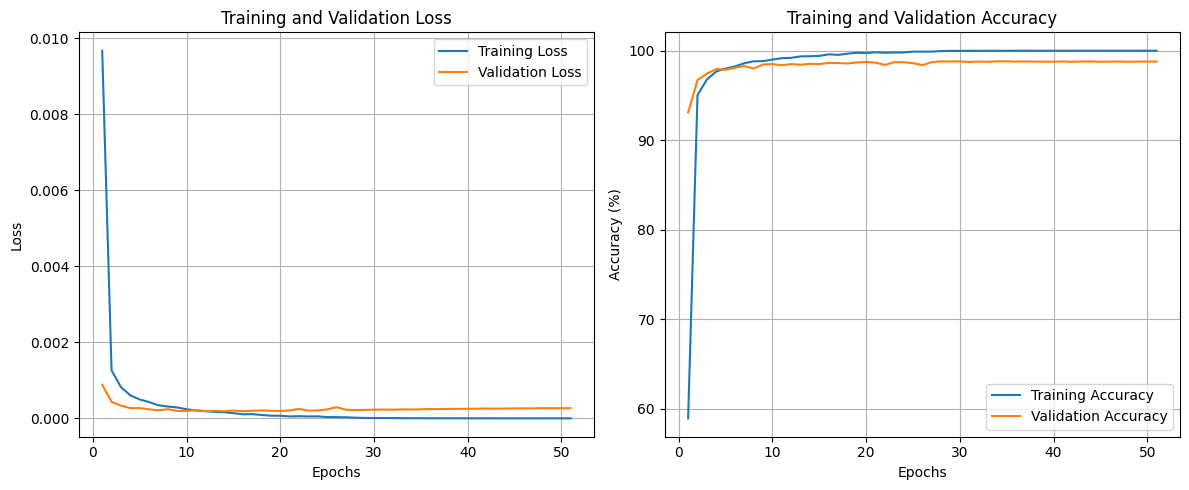

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_metrics['loss'])+1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, train_metrics['loss'], label='Training Loss')
plt.plot(epochs, val_metrics['loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, train_metrics['acc'], label='Training Accuracy')
plt.plot(epochs, val_metrics['acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Plot a confusion matrix to check which MNIST digit is most frequently confused with which other digit. Can you explain why?

The most confused digit is the 6 that is confused with 5. This happens because of similarities in the way of writing them.


<Figure size 1000x800 with 0 Axes>

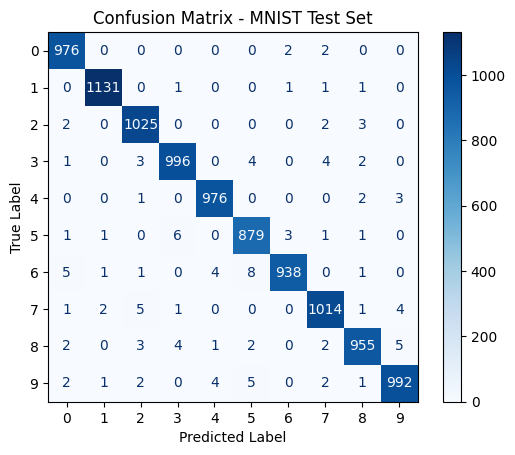

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get true labels from test_loader
true_labels = []
for _, targets in test_loader:
    true_labels.extend(targets.cpu().numpy())

# Get predicted labels from test_metrics
predicted_labels = test_metrics['predictions'].cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Define class names (digits 0-9)
class_names = [str(i) for i in range(10)]

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - MNIST Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### For the remaining tasks try to integrate the changes in the code above while avoiding duplicate code as much as possible. For every task, introduce flags (i.e., function arguments) to the main() function to enable the new functionality of the task. It should always be possible to run the original implementation above. Finally, call the main function with the correct flags for each task in the cells below.

### 6. The LeNet5 architecture can also be implemented using the sequential API ([see documentation](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)). Reimplement it with this API and run training + evaluation once to verify it works.

In [ ]:
from torch.nn.modules.flatten import Flatten
import torch.nn as nn
from torch.nn.modules import padding

class LeNet_SEQ(nn.Module):
  def __init__(self):
    super(LeNet_SEQ, self).__init__()


    # Convolutional layers (features extractor)
    self.features = nn.Sequential(
        padding.ZeroPad2d(2),
        nn.Conv2d(1, 6, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(16*5*5, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
        )

  def forward(self, x):

    x = self.features(x)

    return x

### 7. Implement adaptive early stopping: if the validation loss did not decrease for K consecutive epochs, stop training.
#### Optional: Select the model based on the best validation loss.

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = LeNet_SEQ().to(device)
train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader = main(net, early_stop=5)

Before training:
	 Training loss 0.01805, Training accuracy 10.44
	 Validation loss 0.00907, Validation accuracy 10.44
	 Test loss 0.00922, Test accuracy 10.28
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00942, Training accuracy 60.93
	 Validation loss 0.00081, Validation accuracy 93.69
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00119, Training accuracy 95.18
	 Validation loss 0.00048, Validation accuracy 95.98
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00077, Training accuracy 96.97
	 Validation loss 0.00035, Validation accuracy 97.18
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00057, Training accuracy 97.68
	 Validation loss 0.00033, Validation accuracy 97.29
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00046, Training accuracy 98.16
	 Validation loss 0.00026, Validation accuracy 97.93
---------------

### 8. Change the dataset in order to train and evaluate the LeNet5 network on [CIFAR10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

In [ ]:
class LeNet_CIFAR(nn.Module):
  def __init__(self):
    super(LeNet_CIFAR, self).__init__()


    # Convolutional layers (features extractor)
    self.features = nn.Sequential(
        nn.Conv2d(3, 6, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(16*5*5, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
        )

  def forward(self, x):

    x = self.features(x)

    return x

In [ ]:

net = LeNet_CIFAR().to(device)

train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader = main(net, dataset='CIFAR10')

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


Before training:
	 Training loss 0.01806, Training accuracy 10.20
	 Validation loss 0.00903, Validation accuracy 9.80
	 Test loss 0.00921, Test accuracy 10.00
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01733, Training accuracy 17.06
	 Validation loss 0.00778, Validation accuracy 27.83
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01440, Training accuracy 32.52
	 Validation loss 0.00658, Validation accuracy 37.99
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01276, Training accuracy 39.85
	 Validation loss 0.00647, Validation accuracy 39.59
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01186, Training accuracy 44.38
	 Validation loss 0.00582, Validation accuracy 44.96
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01119, Training accuracy 48.31
	 Validation loss 0.00557, Validation accuracy 48.23
----------------

### 9. Try to improve the performance on CIFAR10 with both:
   *   data-augmentation
   *   dropout

In [ ]:

class LeNet_CIFAR_DROP(nn.Module):
  def __init__(self,dropout_rate):
    super(LeNet_CIFAR_DROP, self).__init__()


    # Convolutional layers (features extractor)
    self.features = nn.Sequential(
        nn.Conv2d(3, 6, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16*5*5, 120),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(84, 10)
        )

  def forward(self, x):

    x = self.features(x)

    return x

In [ ]:
net = LeNet_CIFAR_DROP(dropout_rate=0.5).to(device)
train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader = main(net, dropout_rate=0.5, dataset='CIFAR10', use_data_augmentation=True)

Before training:
	 Training loss 0.01806, Training accuracy 9.97
	 Validation loss 0.00903, Validation accuracy 10.03
	 Test loss 0.00922, Test accuracy 10.00
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01798, Training accuracy 12.18
	 Validation loss 0.00878, Validation accuracy 17.60
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01650, Training accuracy 19.46
	 Validation loss 0.00775, Validation accuracy 25.59
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01510, Training accuracy 25.63
	 Validation loss 0.00721, Validation accuracy 31.82
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01449, Training accuracy 29.43
	 Validation loss 0.00681, Validation accuracy 35.81
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01398, Training accuracy 32.50
	 Validation loss 0.00662, Validation accuracy 37.66
----------------

### 10. Use the ResNet18 class from Pytorch to train and evaluate a ResNet on CIFAR10 (make sure it works, but if it takes too long, you don't have to train until convergence).

In [ ]:
from torchvision import models
model = models.resnet18().to(device)

In [ ]:
#train resnet
train_metrics, val_metrics, test_metrics, train_loader, val_loader, test_loader = main(model, dataset='CIFAR10')

Before training:
	 Training loss 0.05417, Training accuracy 0.00
	 Validation loss 0.02708, Validation accuracy 0.00
	 Test loss 0.02764, Test accuracy 0.00
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01428, Training accuracy 38.01
	 Validation loss 0.00558, Validation accuracy 48.34
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01011, Training accuracy 53.72
	 Validation loss 0.00519, Validation accuracy 53.35
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00831, Training accuracy 62.40
	 Validation loss 0.00493, Validation accuracy 56.60
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00685, Training accuracy 69.03
	 Validation loss 0.00441, Validation accuracy 61.50
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00569, Training accuracy 74.10
	 Validation loss 0.00485, Validation accuracy 60.62
------------------